# Credit Card Default Prediction — Classification Pipeline

**Research Question:** Can demographic features and payment history predict whether a customer will default next month? How do different classifiers and class imbalance strategies compare on this problem?

**Dataset:** UCI Default of Credit Card Clients  
- 30,000 records, 23 features, 1 target variable  
- Target: 0 = no default, 1 = default (~22% positive → class imbalance)

**Pipeline structure:**
1. **EDA** — Explore the data
2. **Preprocessing** — Invalid value correction + StandardScaler
3. **Main Experiment** — 4 models × 3 imbalance strategies, 5-fold Stratified CV (10 effective configs)
4. **Visualization** — ROC curve, Confusion Matrix, Feature Importance

**Comparison axes:**
| Decision point | Approach |
|---|---|
| Class imbalance | Compare: None vs class_weight vs SMOTE |
| Models | Compare: DT, NB, KNN, RF |

**Note:** class_weight is only applicable to DT and RF. NB and KNN do not support this parameter, so they are evaluated under None and SMOTE only (10 total configurations).

## Step 1 — EDA (Exploratory Data Analysis)

First look at the data: shape, first rows, summary statistics, missing value check, target distribution.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_loader import load_dataset

X, y, _variables = load_dataset()

print(_variables)

# Merge into a single DataFrame
df = X.copy()
df['default'] = y.values  # add target column

# --- Basic info ---
print("=== Shape ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n=== Summary statistics ===")
display(df.describe().round(2))

print("\n=== Missing values ===")
print(df.isnull().sum().sum(), "missing values found.")

print("\n=== Target variable distribution ===")
counts = df['default'].value_counts()
pct = df['default'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': counts, 'Percent (%)': pct.round(1)}))

✓ Veri UCI reposundan yüklendi.
   X : 30,000 satır × 23 sütun | dtype: int64
   y : 30,000 satır × 1 sütun | sütun: 'default'
   name     role     type      demographic                 description units  \
0    ID       ID  Integer              NaN                         NaN  None   
1    X1  Feature  Integer              NaN                   LIMIT_BAL  None   
2    X2  Feature  Integer              Sex                         SEX  None   
3    X3  Feature  Integer  Education Level                   EDUCATION  None   
4    X4  Feature  Integer   Marital Status                    MARRIAGE  None   
5    X5  Feature  Integer              Age                         AGE  None   
6    X6  Feature  Integer              NaN                       PAY_0  None   
7    X7  Feature  Integer              NaN                       PAY_2  None   
8    X8  Feature  Integer              NaN                       PAY_3  None   
9    X9  Feature  Integer              NaN                       PAY_4  N

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,default
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,167484.32,1.60,1.85,1.55,35.49,-0.02,-0.13,-0.17,-0.22,-0.27,...,43262.95,40311.40,38871.76,5663.58,5921.16,5225.68,4826.08,4799.39,5215.50,0.22
std,129747.66,0.49,0.79,0.52,9.22,1.12,1.20,1.20,1.17,1.13,...,64332.86,60797.16,59554.11,16563.28,23040.87,17606.96,15666.16,15278.31,17777.47,0.42
min,10000.00,1.00,0.00,0.00,21.00,-2.00,-2.00,-2.00,-2.00,-2.00,...,-170000.00,-81334.00,-339603.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,50000.00,1.00,1.00,1.00,28.00,-1.00,-1.00,-1.00,-1.00,-1.00,...,2326.75,1763.00,1256.00,1000.00,833.00,390.00,296.00,252.50,117.75,0.00
50%,140000.00,2.00,2.00,2.00,34.00,0.00,0.00,0.00,0.00,0.00,...,19052.00,18104.50,17071.00,2100.00,2009.00,1800.00,1500.00,1500.00,1500.00,0.00
75%,240000.00,2.00,2.00,2.00,41.00,0.00,0.00,0.00,0.00,0.00,...,54506.00,50190.50,49198.25,5006.00,5000.00,4505.00,4013.25,4031.50,4000.00,0.00
max,1000000.00,2.00,6.00,3.00,79.00,8.00,8.00,8.00,8.00,8.00,...,891586.00,927171.00,961664.00,873552.00,1684259.00,896040.00,621000.00,426529.00,528666.00,1.00



=== Missing values ===
0 missing values found.

=== Target variable distribution ===
         Count  Percent (%)
default                    
0        23364         77.9
1         6636         22.1


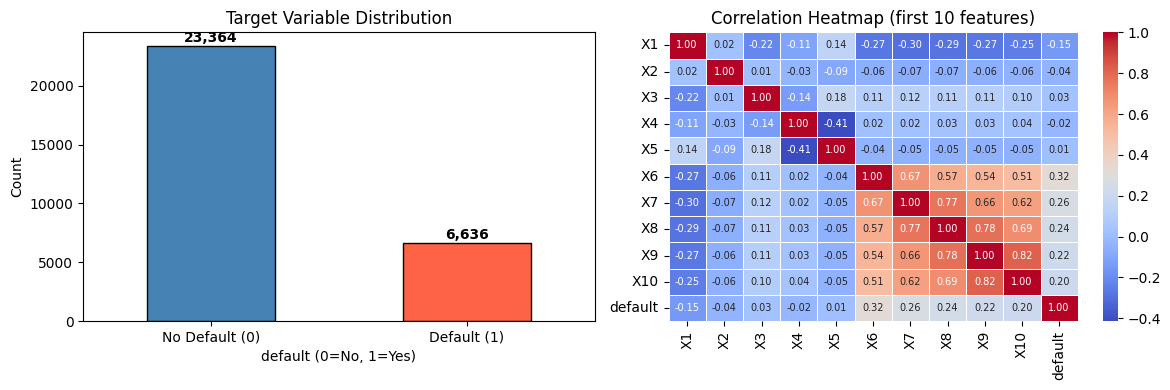

In [2]:
# --- Visual 1: Target distribution (class imbalance) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Target Variable Distribution')
axes[0].set_xlabel('default (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)
for bar, count in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Correlation heatmap (first 10 features)
top_cols = list(X.columns[:10]) + ['default']
corr = df[top_cols].corr()
sns.heatmap(corr, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
axes[1].set_title('Correlation Heatmap (first 10 features)')

plt.tight_layout()
plt.show()


## Step 2 — Preprocessing

These decisions remain the same across all experiments — they are not part of the comparison.

- **Invalid categorical values:** Undocumented values in EDUCATION and MARRIAGE → merged into the "Other" category
- **Scaling:** StandardScaler — applied inside the pipeline (fitted only on training data in each CV fold → prevents data leakage)
- Class imbalance is not handled here → addressed comparatively in the main experiment

In [3]:
from sklearn.preprocessing import StandardScaler

X_clean = X.copy()

# =====================================================================
# nspect raw values in the data 
# what values exist and their frequencies
# =====================================================================
print("=== X3 (EDUCATION) — raw value distribution ===")
print(X_clean['X3'].value_counts().sort_index())
print("\nDocumented values: 1=Grad School, 2=University, 3=High School, 4=Other")
print("Any value outside these → undocumented → will be merged into 'Other' (4)\n")

print("=== X4 (MARRIAGE) — raw value distribution ===")
print(X_clean['X4'].value_counts().sort_index())
print("\nDocumented values: 1=Married, 2=Single, 3=Other")
print("If 0 appears → undocumented → will be merged into 'Other' (3)\n")

# =====================================================================
# Fix based on what we observed
# =====================================================================
valid_X3 = {1, 2, 3, 4}
valid_X4 = {1, 2, 3}

invalid_X3 = set(X_clean['X3'].unique()) - valid_X3
invalid_X4 = set(X_clean['X4'].unique()) - valid_X4
print(f"X3 invalid values (to be fixed): {sorted(invalid_X3)}")
print(f"X4 invalid values (to be fixed): {sorted(invalid_X4)}")

X_clean['X3'] = X_clean['X3'].replace({v: 4 for v in invalid_X3})
X_clean['X4'] = X_clean['X4'].replace({v: 3 for v in invalid_X4})

print("\n--- After correction ---")
print("X3 unique:", sorted(X_clean['X3'].unique()), "  ← should be 1,2,3,4 only")
print("X4 unique:", sorted(X_clean['X4'].unique()), "  ← should be 1,2,3 only")

# --- Flatten target variable ---
y_arr = y.values.ravel()  # shape (30000,)

# --- StandardScaler is NOT applied here ---
# Why? Fitting on the full dataset would cause data leakage.
# The scaler is inside the pipeline → fitted only on training data
# in each CV fold, then transforms the test fold.
X_processed = X_clean.values  # convert to numpy array for pipeline

print("StandardScaler will be applied inside the pipeline (prevents data leakage).")


=== X3 (EDUCATION) — raw value distribution ===
X3
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Documented values: 1=Grad School, 2=University, 3=High School, 4=Other
Any value outside these → undocumented → will be merged into 'Other' (4)

=== X4 (MARRIAGE) — raw value distribution ===
X4
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

Documented values: 1=Married, 2=Single, 3=Other
If 0 appears → undocumented → will be merged into 'Other' (3)

X3 invalid values (to be fixed): [np.int64(0), np.int64(5), np.int64(6)]
X4 invalid values (to be fixed): [np.int64(0)]

--- After correction ---
X3 unique: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]   ← should be 1,2,3,4 only
X4 unique: [np.int64(1), np.int64(2), np.int64(3)]   ← should be 1,2,3 only
StandardScaler will be applied inside the pipeline (prevents data leakage).


## Step 3 — Main Experiment: 4 Models × Imbalance Strategies

**Validation:** 5-fold Stratified Cross-Validation  
→ Data is split into 5 parts; each time 4 parts are used for training, 1 for testing. Results are averaged across 5 folds.  
→ Avoids dependence on a single train/test split.

**Class imbalance strategies:**

| Strategy | Description | Applicable models |
|---|---|---|
| **None (baseline)** | No adjustment for class imbalance | All 4 models |
| **class_weight='balanced'** | Model assigns higher weight to the minority class | DT, RF only |
| **SMOTE** | Synthetic minority examples generated in training set | All 4 models |

**Models:** Decision Tree, Naïve Bayes, k-NN (k=5), Random Forest  
**Total configurations:** 10 (NB and k-NN do not support class_weight)

Note: SMOTE is applied only to training folds (test fold is untouched) → guaranteed by `imblearn.pipeline.Pipeline`.

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# --- CV setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Model definitions ---
base_models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Naïve Bayes':   GaussianNB(),
    'k-NN (k=5)':    KNeighborsClassifier(n_neighbors=5),
    'Random Forest':  RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
}

# --- Class imbalance strategies ---
# StandardScaler is the first pipeline step — fitted only on training
# data in each fold, then transforms the test fold.

def make_configs(base_models):
    """Generates experiment configurations. class_weight is only
    applied to models that support it (DT, RF). NB and KNN are
    evaluated under None and SMOTE only → 10 total configs."""
    import copy
    configs = []
    for model_name, model in base_models.items():
        # --- Strategy 1: None (baseline) ---
        pipe_none = ImbPipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        configs.append((model_name, 'None', pipe_none))

        # --- Strategy 2: class_weight='balanced' (DT and RF only) ---
        if hasattr(model, 'class_weight'):
            model_cw = copy.deepcopy(model)
            model_cw.set_params(class_weight='balanced')
            pipe_cw = ImbPipeline([
                ('scaler', StandardScaler()),
                ('model', model_cw)
            ])
            configs.append((model_name, 'class_weight', pipe_cw))

        # --- Strategy 3: SMOTE ---
        pipe_smote = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('model', model)
        ])
        configs.append((model_name, 'SMOTE', pipe_smote))

    return configs

configs = make_configs(base_models)
print(f"Total configurations: {len(configs)}")
for name, strategy, _ in configs:
    print(f"  {name:20s} | {strategy}")


Total configurations: 10
  Decision Tree        | None
  Decision Tree        | class_weight
  Decision Tree        | SMOTE
  Naïve Bayes          | None
  Naïve Bayes          | SMOTE
  k-NN (k=5)           | None
  k-NN (k=5)           | SMOTE
  Random Forest        | None
  Random Forest        | class_weight
  Random Forest        | SMOTE


In [5]:
# --- Experiment Configuration Table (for report) ---
config_table = pd.DataFrame({
    'Model': ['Decision Tree', 'Naïve Bayes', 'k-NN (k=5)', 'Random Forest'],
    'None (Baseline)': ['✓', '✓', '✓', '✓'],
    'class_weight': ['✓', '—', '—', '✓'],
    'SMOTE': ['✓', '✓', '✓', '✓'],
})

print("=== Experiment Configurations ===")
print("(✓ = evaluated, — = not supported by model)\n")
display(config_table.set_index('Model'))
print(f"\nTotal configurations: {len(configs)}")
print("Note: NB and KNN do not support class_weight → excluded from that strategy.")


=== Experiment Configurations ===
(✓ = evaluated, — = not supported by model)



,None (Baseline),class_weight,SMOTE
Model,,,
Decision Tree,✓,✓,✓
Naïve Bayes,✓,—,✓
k-NN (k=5),✓,—,✓
Random Forest,✓,✓,✓



Total configurations: 10
Note: NB and KNN do not support class_weight → excluded from that strategy.


### 3.1 — Run Cross-Validation

5-fold CV is run for each of the 10 configurations.  
Accuracy, precision, recall, F1, and ROC-AUC are computed per fold → mean and std across 5 folds are reported.

In [6]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = []

print(f"Running cross-validation ({len(configs)} configurations × 5 folds)...")
for model_name, strategy, pipeline in configs:
    cv_results = cross_validate(
        pipeline, X_processed, y_arr,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    row = {
        'Model': model_name,
        'Strategy': strategy,
    }
    for metric in scoring:
        key = f'test_{metric}'
        row[f'{metric}_mean'] = cv_results[key].mean()
        row[f'{metric}_std']  = cv_results[key].std()

    results.append(row)
    print(f"  ✓ {model_name:20s} | {strategy:12s} | F1={row['f1_mean']:.4f} ± {row['f1_std']:.4f}")

results_df = pd.DataFrame(results)
print("\nDone.")


Running cross-validation (10 configurations × 5 folds)...
  ✓ Decision Tree        | None         | F1=0.4538 ± 0.0142
  ✓ Decision Tree        | class_weight | F1=0.5008 ± 0.0133
  ✓ Decision Tree        | SMOTE        | F1=0.4909 ± 0.0114
  ✓ Naïve Bayes          | None         | F1=0.4951 ± 0.0208
  ✓ Naïve Bayes          | SMOTE        | F1=0.4013 ± 0.0067
  ✓ k-NN (k=5)           | None         | F1=0.4219 ± 0.0086
  ✓ k-NN (k=5)           | SMOTE        | F1=0.4410 ± 0.0094
  ✓ Random Forest        | None         | F1=0.4666 ± 0.0068
  ✓ Random Forest        | class_weight | F1=0.5404 ± 0.0093
  ✓ Random Forest        | SMOTE        | F1=0.5356 ± 0.0117

Done.


### 3.2 — Results Table

5-fold CV means for all 10 configurations. Each metric is shown as `mean ± std`.  
- **Accuracy** can be misleading (predicting majority class alone yields ~78%)  
- **Recall** shows what fraction of actual defaults we catch — class imbalance effect is visible here  
- **F1** balances precision and recall  
- **ROC-AUC** threshold-independent overall performance

In [7]:
# --- Format results table ---
display_df = results_df[['Model', 'Strategy']].copy()

# Readable format: "0.8123 ± 0.0045"
for metric in scoring:
    display_df[metric] = results_df.apply(
        lambda r: f"{r[f'{metric}_mean']:.4f} ± {r[f'{metric}_std']:.4f}", axis=1
    )

print("=== Main Experiment Results (5-Fold Stratified CV) ===\n")
display(display_df)


=== Main Experiment Results (5-Fold Stratified CV) ===



,Model,Strategy,accuracy,precision,recall,f1,roc_auc
0,Decision Tree,None,0.8070 ± 0.0032,0.6075 ± 0.0178,0.3630 ± 0.0219,0.4538 ± 0.0142,0.7256 ± 0.0048
1,Decision Tree,class_weight,0.7347 ± 0.0116,0.4294 ± 0.0165,0.6013 ± 0.0134,0.5008 ± 0.0133,0.7290 ± 0.0057
2,Decision Tree,SMOTE,0.7502 ± 0.0143,0.4485 ± 0.0225,0.5440 ± 0.0218,0.4909 ± 0.0114,0.7149 ± 0.0128
3,Naïve Bayes,None,0.7024 ± 0.0445,0.4030 ± 0.0429,0.6542 ± 0.0472,0.4951 ± 0.0208,0.7367 ± 0.0054
4,Naïve Bayes,SMOTE,0.4225 ± 0.0305,0.2607 ± 0.0080,0.8740 ± 0.0240,0.4013 ± 0.0067,0.7303 ± 0.0045
5,k-NN (k=5),None,0.7913 ± 0.0035,0.5447 ± 0.0130,0.3443 ± 0.0068,0.4219 ± 0.0086,0.7008 ± 0.0076
6,k-NN (k=5),SMOTE,0.6596 ± 0.0078,0.3464 ± 0.0083,0.6070 ± 0.0128,0.4410 ± 0.0094,0.6843 ± 0.0081
7,Random Forest,None,0.8193 ± 0.0034,0.6729 ± 0.0185,0.3571 ± 0.0042,0.4666 ± 0.0068,0.7805 ± 0.0061
8,Random Forest,class_weight,0.7874 ± 0.0033,0.5178 ± 0.0068,0.5652 ± 0.0131,0.5404 ± 0.0093,0.7766 ± 0.0066
9,Random Forest,SMOTE,0.7827 ± 0.0066,0.5081 ± 0.0135,0.5663 ± 0.0115,0.5356 ± 0.0117,0.7729 ± 0.0067


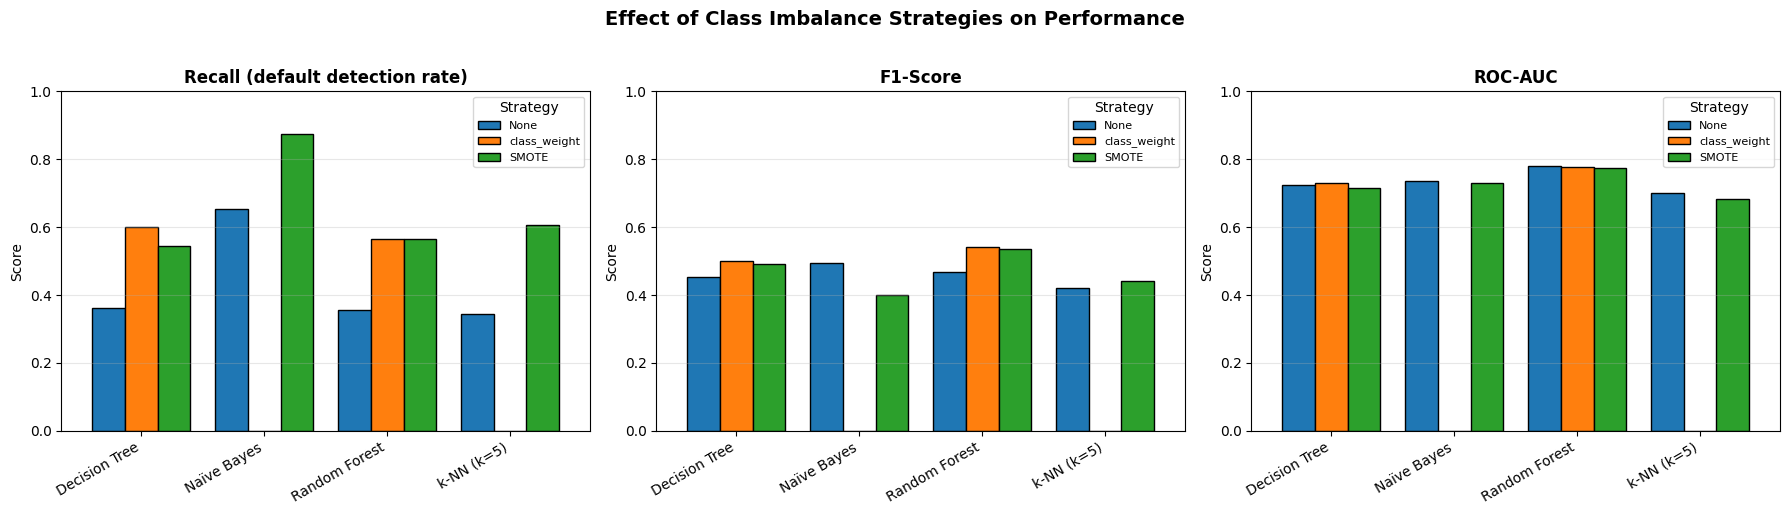

In [8]:
# --- Visual: Strategy × Model comparison charts ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['recall_mean', 'f1_mean', 'roc_auc_mean']
titles = ['Recall (default detection rate)', 'F1-Score', 'ROC-AUC']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    pivot = results_df.pivot(index='Model', columns='Strategy', values=metric)
    # Reorder columns; reindex so missing combos appear as NaN (no bar)
    pivot = pivot.reindex(columns=['None', 'class_weight', 'SMOTE'])
    pivot.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(title='Strategy', fontsize=8)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Effect of Class Imbalance Strategies on Performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Step 4 — ROC Curve, Confusion Matrix, Feature Importance

A single train/test split is used for ROC curve and Confusion Matrix (CV averages cannot produce these plots).  
This split is for visualization only — the main results are in the CV table above.

Best strategy: class_weight



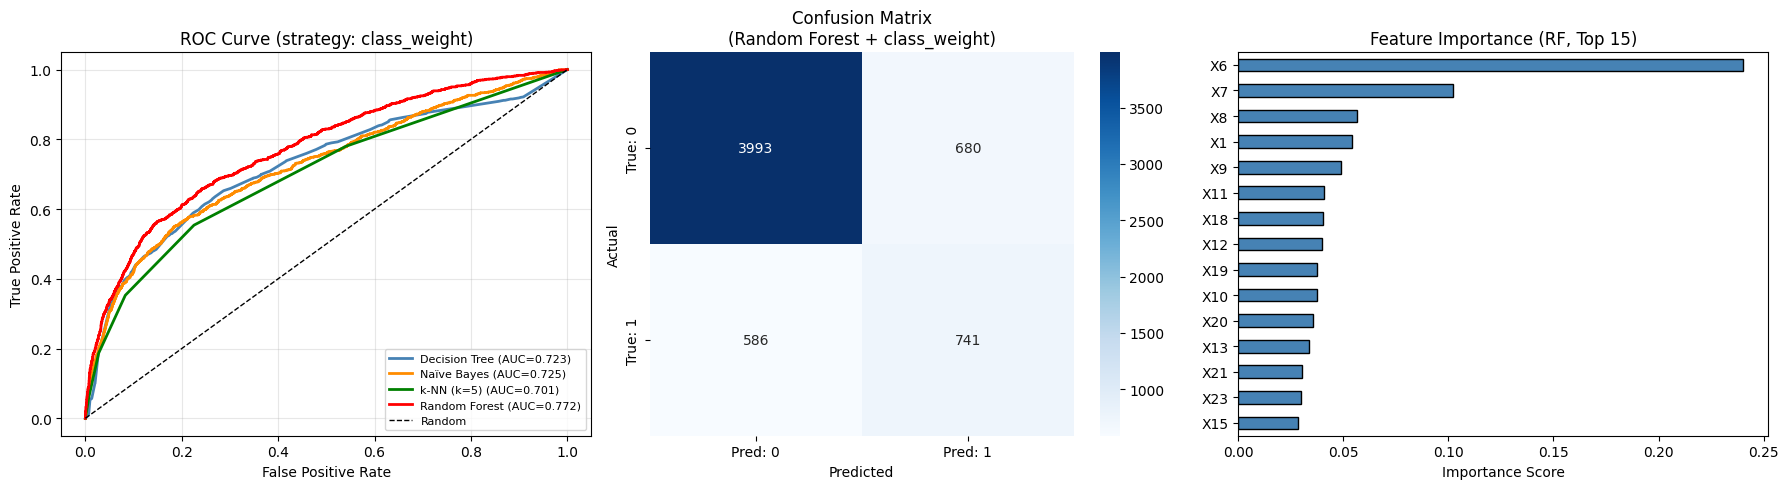

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import copy

# --- Find best strategy from main experiment ---
best_strategy = results_df.loc[results_df['f1_mean'].idxmax(), 'Strategy']
print(f"Best strategy: {best_strategy}\n")

# --- Single split for visualization (does not affect CV results) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_arr, test_size=0.20, random_state=42, stratify=y_arr
)

# Train all 4 models with the best strategy (pipeline includes scaler)
vis_models = {}
for model_name, model in base_models.items():
    m = copy.deepcopy(model)
    if best_strategy == 'class_weight' and hasattr(m, 'class_weight'):
        m.set_params(class_weight='balanced')
    steps = [('scaler', StandardScaler())]
    if best_strategy == 'SMOTE':
        steps.append(('smote', SMOTE(random_state=42)))
    steps.append(('model', m))
    pipe = ImbPipeline(steps)
    pipe.fit(X_train, y_train)
    vis_models[model_name] = pipe

# === ROC Curve ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['steelblue', 'darkorange', 'green', 'red']
for (name, pipe), color in zip(vis_models.items(), colors):
    y_prob = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve (strategy: {best_strategy})')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(alpha=0.3)

# === Confusion Matrix (best model) ===
best_model_name = results_df.loc[results_df['f1_mean'].idxmax(), 'Model']
best_pipe = vis_models[best_model_name]
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['True: 0', 'True: 1'])
axes[1].set_title(f'Confusion Matrix\n({best_model_name} + {best_strategy})')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# === Feature Importance (Random Forest) ===
rf_pipe = vis_models['Random Forest']
rf_model = rf_pipe.named_steps['model']
importances = pd.Series(rf_model.feature_importances_, index=X_clean.columns)
top15 = importances.nlargest(15).sort_values()
top15.plot(kind='barh', ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Feature Importance (RF, Top 15)')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()
